In [3]:
# ============================================
# STEP 2 — DATA GENERATION
# Flexible load profiles for one bidding hour
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------------
# Parameters
# -----------------------------

N_total = 300          # total profiles
N_in = 100             # in-sample profiles
N_out = 200            # out-of-sample profiles

M = 60                 # minutes in one bidding hour

P_min = 220            # minimum consumption [kW]
P_max = 600            # maximum consumption [kW]
max_ramp = 35          # max minute-to-minute change [kW]

# -----------------------------
# Generate stochastic load profiles
# -----------------------------

load_profiles = np.zeros((N_total, M))

for s in range(N_total):

    # random starting consumption
    load_profiles[s, 0] = np.random.uniform(P_min, P_max)

    for m in range(1, M):

        # random minute-to-minute change
        step = np.random.uniform(-max_ramp, max_ramp)

        load_profiles[s, m] = load_profiles[s, m-1] + step

        # enforce bounds
        load_profiles[s, m] = np.clip(load_profiles[s, m], P_min, P_max)


# -----------------------------
# Split into in-sample and out-of-sample
# -----------------------------

indices = np.random.permutation(N_total)

in_sample_idx = indices[:N_in]
out_sample_idx = indices[N_in:]

load_in = load_profiles[in_sample_idx, :]
load_out = load_profiles[out_sample_idx, :]

# For FCR-D Up, available flexibility equals reducible consumption
F_up_in = load_in.copy()
F_up_out = load_out.copy()

print("Generated load profiles:", load_profiles.shape)
print("In-sample profiles:", load_in.shape)
print("Out-of-sample profiles:", load_out.shape)
print("Min load:", load_profiles.min())
print("Max load:", load_profiles.max())
print("Max observed ramp:", np.max(np.abs(np.diff(load_profiles, axis=1))))

np.save("../data/load_profiles.npy", load_profiles)
np.save("../data/load_in.npy", load_in)
np.save("../data/load_out.npy", load_out)
np.save("../data/F_up_in.npy", F_up_in)
np.save("../data/F_up_out.npy", F_up_out)



Generated load profiles: (300, 60)
In-sample profiles: (100, 60)
Out-of-sample profiles: (200, 60)
Min load: 220.0
Max load: 600.0
Max observed ramp: 34.99918556712436


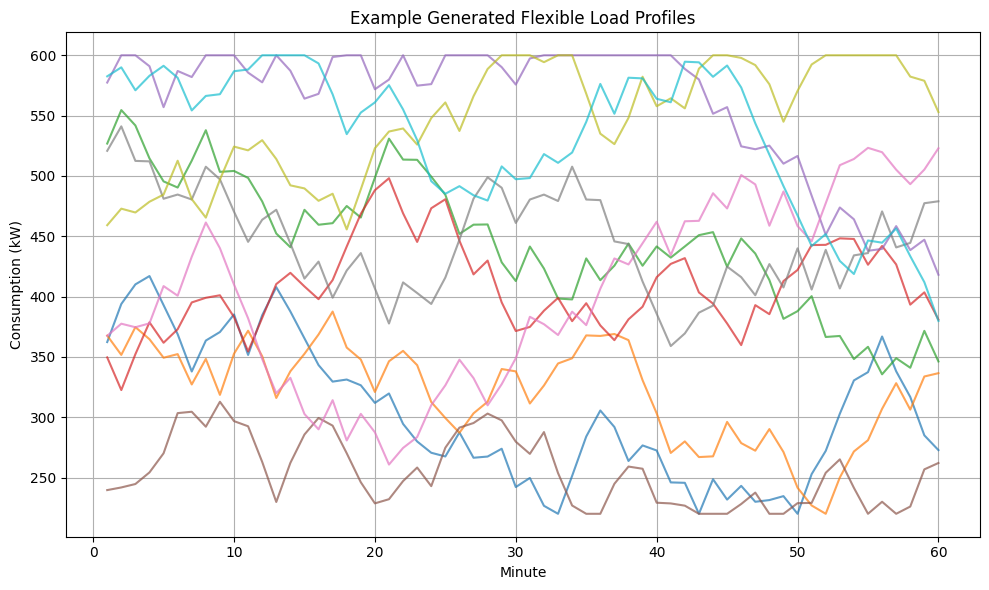

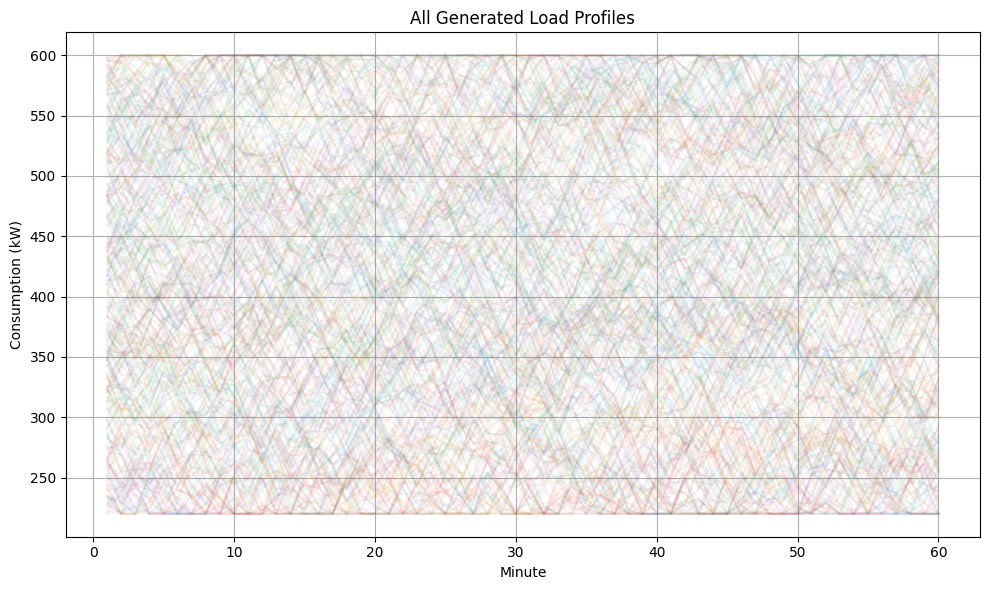

In [4]:
# ============================================
# Plot generated load profiles
# ============================================

plt.figure(figsize=(10, 6))

for s in range(10):
    plt.plot(range(1, M + 1), load_profiles[s, :], alpha=0.7)

plt.xlabel("Minute")
plt.ylabel("Consumption (kW)")
plt.title("Example Generated Flexible Load Profiles")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

for s in range(N_total):
    plt.plot(range(1, M + 1), load_profiles[s, :], alpha=0.08)

plt.xlabel("Minute")
plt.ylabel("Consumption (kW)")
plt.title("All Generated Load Profiles")
plt.grid(True)
plt.tight_layout()
plt.show()
